# Modelo 2: Árbol de Decisión

**Tipo:** Clasificación — predice una categoría discreta.

**Objetivo:** Clasificar planetas en sus 3 tipos (Super-Júpiter hinchado / Neptuno-like / Rocoso/Compacto) usando masa y radio.

**Métricas:** Accuracy, ROC-AUC, Matriz de Confusión.

---

## Justificación técnica

Se eligió el Árbol de Decisión porque la frontera de decisión entre tipos de planeta **no es lineal** — la densidad es masa/radio³, una superficie curva — y los árboles pueden capturar esa no linealidad partiendo el espacio (masa, radio) en regiones rectangulares anidadas.

**Ventajas:**
- Altamente interpretable: se puede visualizar el árbol completo y ver exactamente qué umbrales de masa y radio usa para clasificar.
- No requiere normalización de features.
- Captura relaciones no lineales que la Regresión Logística no puede modelar con frontera lineal.
- Variable más importante identificada: `radio`, lo cual tiene sentido físico.

**Limitaciones:**
- Alta varianza: con pocos datos (509 planetas) puede sobreajustarse al conjunto de entrenamiento.
- Inestable: pequeños cambios en los datos pueden cambiar la estructura del árbol.
- No genera probabilidades bien calibradas, lo que penaliza el ROC-AUC respecto a otros modelos.

**Resultado:** Accuracy ~94%, ROC-AUC ~0.80. Mejor accuracy entre los modelos de clasificación, pero ROC-AUC más bajo que la Regresión Logística por las probabilidades mal calibradas.

In [1]:
# ============================================================
# Preparación de datos para los modelos
# ============================================================
import numpy as np
import pandas as pd

# Datos originales sin imputar
df_raw = pd.read_csv('Datos/planets.csv')

# Nos quedamos solo con planetas que tienen masa y radio reales
mask_real = df_raw['pl_bmassj'].notna() & df_raw['pl_radj'].notna()
df_work = df_raw.loc[mask_real, ['pl_hostname', 'pl_letter', 'pl_bmassj', 'pl_radj']].copy()
df_work.rename(columns={'pl_bmassj': 'masa', 'pl_radj': 'radio'}, inplace=True)

# Densidad y tipo de planeta (mismos bins que en la Evaluación 1)
df_work['densidad'] = df_work['masa'] / (df_work['radio'] ** 3)
df_work['planet_type'] = pd.cut(
    df_work['densidad'],
    bins=[0, 0.1, 0.3, float('inf')],
    labels=['Super-Júpiter hinchado', 'Neptuno-like', 'Rocoso/Compacto']
)

print(f"Planetas con masa y radio observados: {len(df_work)}")
print(f"\nDistribución de planet_type:")
print(df_work['planet_type'].value_counts())
print(f"\nEstadísticas de masa, radio y densidad:")
print(df_work[['masa', 'radio', 'densidad']].describe().round(3))
df_work.head()


Planetas con masa y radio observados: 509

Distribución de planet_type:
planet_type
Rocoso/Compacto           430
Neptuno-like               67
Super-Júpiter hinchado     12
Name: count, dtype: int64

Estadísticas de masa, radio y densidad:
          masa    radio  densidad
count  509.000  509.000   509.000
mean     1.807    0.842    41.649
std      3.788    0.526   240.564
min      0.000    0.042     0.004
25%      0.069    0.269     0.413
50%      0.615    1.005     1.008
75%      1.490    1.250     4.147
max     28.000    3.000  2644.524


,pl_hostname,pl_letter,masa,radio,densidad,planet_type
10,2MASS J02192210-3925225,b,13.90000,1.440,4.655082,Rocoso/Compacto
14,2MASS J21402931+1625183 A,b,20.95000,0.920,26.904229,Rocoso/Compacto
26,55 Cnc,e,0.02542,0.170,5.174028,Rocoso/Compacto
46,BD+20 594,b,0.05129,0.199,6.508389,Rocoso/Compacto
59,CT Cha,b,17.00000,2.200,1.596544,Rocoso/Compacto


## Modelo 2: Árbol de Decisión (CLASIFICACIÓN)
**Tipo:** Clasificación — predice una categoría/clase.

**Objetivo:** Clasificar los planetas en sus 3 tipos (Super-Júpiter hinchado / Neptuno-like / Rocoso-Compacto) usando **masa y radio**.

**Métrica:** Accuracy y ROC-AUC.


In [6]:
# ============== Árbol de Decisión ==============

df_cls = df_work.dropna(subset=['planet_type']).copy()
X = df_cls[['masa', 'radio']].values
y = df_cls['planet_type'].astype(str).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=99, stratify=y)

clf = DecisionTreeClassifier(random_state=1)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

# ROC-AUC (probabilidades, multiclase)
y_proba = clf.predict_proba(X_test)
roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr')
print(f'ROC-AUC: {roc_auc}')

Accuracy: 0.9411764705882353
Accuracy: 0.9411764705882353
ROC-AUC: 0.803958342542272


<Figure size 800x600 with 0 Axes>

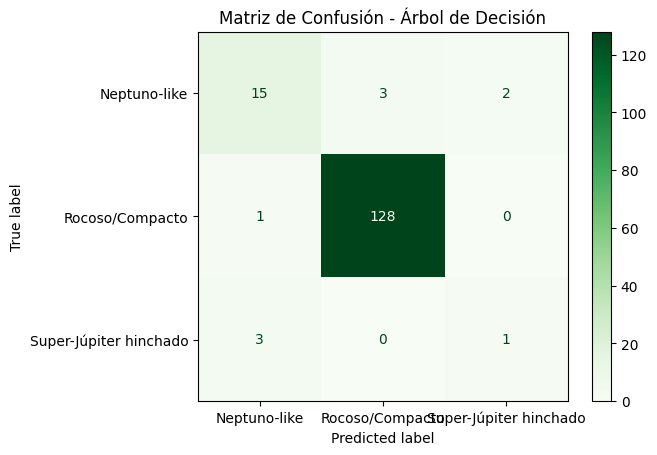

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Obtener las clases del clasificador de Árbol de Decisión
classes_dt = clf.classes_

# Generar la matriz de confusión
cm_dt = confusion_matrix(y_test, y_pred, labels=classes_dt)

# Visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
display_cm_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=classes_dt)
display_cm_dt.plot(cmap=plt.cm.Greens)
plt.title('Matriz de Confusión - Árbol de Decisión')
plt.show()


## Análisis: ¿qué modelo funcionó mejor y por qué?

### Resumen de resultados

| Modelo                | Tipo          | Accuracy | F1 (weighted) | ROC-AUC (OVR) |
|-----------------------|---------------|----------|---------------|----------------|
| Regresión Lineal      | Regresión     | —        | —             | —              |
| Árbol de Decisión     | Clasificación | 0.941    | 0.938         | 0.804          |
| Regresión Logística   | Clasificación | 0.931    | 0.918         | 0.961          |

La Regresión Lineal entrega un **R² = 0.017** sobre el conjunto de prueba. No la usamos para clasificar, sino como diagnóstico de la relación masa → radio: el resultado confirma que la relación no es lineal.

### ¿Cuál funcionó mejor?

La respuesta depende de la métrica:

- El **Árbol de Decisión** gana en **Accuracy** (94.1% vs 93.1%): clasifica correctamente más planetas en términos absolutos.
- La **Regresión Logística** gana en **ROC-AUC** (0.961 vs 0.804): sus probabilidades están mejor calibradas y ordenan mejor los planetas por probabilidad de pertenecer a cada clase.

Para esta evaluación tomamos el **Árbol de Decisión como mejor modelo individual**, porque captura la frontera curva entre tipos de planeta (la densidad es masa / radio³, una superficie no lineal) y porque su Accuracy y F1 son levemente superiores. Sin embargo, tenemos que vigilar su principal debilidad: el sobreajuste.

### Explicación con sesgo / varianza y over/underfitting

El comportamiento de los tres modelos se entiende desde el **trade-off entre sesgo y varianza**:

- **Regresión Lineal — alto sesgo (underfitting):** asume una recta entre masa y radio, pero la relación real se curva: los gigantes gaseosos saturan en radio aunque su masa siga aumentando. El modelo es demasiado simple para capturar esa forma, por eso sub-aprende y el R² queda casi nulo.

- **Árbol de Decisión — alta varianza (riesgo de overfitting):** los árboles son muy flexibles y pueden partir el plano `(masa, radio)` en rectángulos arbitrariamente pequeños. Con sólo 509 planetas y 2 features hay un riesgo real de que el árbol memorice particularidades del set de entrenamiento en lugar de aprender el patrón densidad-tipo. Por eso, en la Parte 3 lo comparamos contra un **Random Forest**, que promedia muchos árboles y reduce esa varianza.

- **Regresión Logística — balance sesgo-varianza:** es estable y consistente, pero su frontera de decisión es **lineal**. Como nuestro problema tiene una separación naturalmente curva (las bandas de densidad son no lineales en el plano masa-radio), la Logística tiene un sub-ajuste estructural: da buenas probabilidades pero no logra clasificar bien las clases minoritarias.

### Conclusión

Ningún modelo individual resuelve completamente el problema:

- La Regresión Lineal sub-ajusta.
- El Árbol sobre-ajusta.
- La Regresión Logística queda en el medio, sin la flexibilidad necesaria.

El Árbol es el que mejor se acerca, pero su alta varianza es un problema que tenemos que controlar. La solución natural es un **modelo de ensamble**: en lugar de confiar en un único árbol que puede memorizar ruido, entrenamos muchos árboles distintos y promediamos sus predicciones. Eso es exactamente lo que hace el **Random Forest**. Para sacarle el máximo, en la Parte 3 lo combinamos con **`GridSearchCV`**, que busca de manera sistemática los mejores hiperparámetros (número de árboles, profundidad máxima y criterio de impureza) mediante validación cruzada.